# Excess mortality in US vs Europe: analysis

In [1]:
%matplotlib inline

import numpy as np
import pylab as plt
import pandas as pd

In [2]:
df = pd.read_csv('us-vs-eu-data.csv')

df

,region,excess20_21,excess21_22,excess22_23,US,population,rel_excess20_21,rel_excess21_22,rel_excess22_23,vacc,gdp,gdp_ppp
0,Alabama,14594.646,10166.475,2864.583,1,5050380.0,0.289,0.201,0.057,42.70,48925.526,48925.526
1,Alaska,806.323,1635.125,1088.679,1,734923.0,0.110,0.222,0.148,50.80,74797.088,74797.088
2,Arizona,21072.415,14881.300,5568.069,1,7272487.0,0.290,0.205,0.077,51.20,56540.740,56540.740
3,Arkansas,7722.338,6601.725,2890.048,1,3028443.0,0.255,0.218,0.095,45.80,47729.279,47729.279
4,California,77367.400,37815.025,25478.025,1,39145060.0,0.198,0.097,0.065,59.10,85748.531,85748.531
...,...,...,...,...,...,...,...,...,...,...,...,...
86,Spain,81017.800,20516.300,41285.000,0,47486935.0,0.171,0.043,0.087,77.26,30488.821,41182.460
87,Sweden,8592.400,2393.400,4918.700,0,10467097.0,0.082,0.023,0.047,62.24,61417.681,60396.714
88,Switzerland,8969.200,3997.000,5652.700,0,8691406.0,0.103,0.046,0.065,63.77,93446.434,77181.375
89,Ukraine,93526.200,89397.000,NaN,0,37367336.0,0.250,0.239,NaN,14.55,4827.846,14289.040


In [3]:
# Averages in 2021/22

ind = df.US == 0
X = df[ind][['rel_excess20_21', 'rel_excess21_22', 'rel_excess22_23']].values
print(f'Europe mean excess: {np.mean(np.nansum(X, axis=1))}')
X = df[ind][['vacc']].values
print(f'Europe mean vacc: {np.mean(X)}')

print('')

ind = (df.US == 1)
X = df[ind][['excess20_21', 'excess21_22', 'excess22_23']].values
e = np.sum(X) / np.sum(df[ind].population.values)

print(f'USA excess: {e * 100}')

Europe mean excess: 0.401175
Europe mean vacc: 53.45775

USA excess: 0.3911317001286831


In [7]:
cols = ['rel_excess20_21', 'rel_excess21_22', 'rel_excess22_23', 'vacc', 'gdp']

print('                       n   Pop   Excess 20/21  Excess 21/22  Excess 22/23  Vacc (Oct 21)          GDP (21)')
print('----------------------------------------------------------------------------------------------------------')

def printline(ind, name):
    a = df[ind][cols].mean().values
    b = df[ind][cols].std().values
    c = np.sum(ind)
    d = df[ind].population.values.sum()
    a[:3] *= 10000
    b[:3] *= 10000
    print(f'{name:20}  {c}  {d/1e+6:.0f}M      '
          f'{np.round(a[0], -1):4.0f}±{np.round(b[0], -1):4.0f}     '
          f'{np.round(a[1], -1):4.0f}±{np.round(b[1], -1):4.0f}       '
          f'{np.round(a[2], -1):3.0f}±{np.round(b[2], -1):3.0f}     '
          f'{a[3]:4.1f}±{b[3]:4.1f}%     '
          f'{np.round(a[4], -2):6,.0f}±{np.round(b[4], -2):6,.0f}'
         )
    
ind = df.US == 0
printline(ind, 'Europe')

ind = (df.US == 0) & (df.gdp >= 40_000)
printline(ind, 'Europe, GDP(PPP)>40k')

ind = (df.US == 0) & (df.vacc >= 40) & (df.vacc <= 70)
printline(ind, 'Europe, 40<vacc<70')

ind = (df.US == 1) & (df.region != 'District of Columbia')
printline(ind, 'USA (w/o DC)')

                       n   Pop   Excess 20/21  Excess 21/22  Excess 22/23  Vacc (Oct 21)          GDP (21)
----------------------------------------------------------------------------------------------------------
Europe                40  730M      2040±1490     1530±1350       460±560     53.5±18.7%     36,500±30,200
Europe, GDP(PPP)>40k  14  295M       630± 590      470± 240       740±430     67.5± 4.7%     70,100±26,000
Europe, 40<vacc<70    22  424M      1770±1330     1350±1180       710±430     57.7± 8.9%     39,100±23,100
USA (w/o DC)          50  331M      1820± 670     1520± 540       580±400     54.2± 8.1%     64,700±11,800


In [5]:
# Correlations in 2021/22

ind = df.US == 0
X = df[ind][['rel_excess21_22', 'gdp', 'vacc']].values
X[:, 1] = np.log(X[:, 1])
print(f'Europe excess/log(gdp): r={np.corrcoef(X.T)[0, 1]:.2f}')
print(f'Europe vacc/log(gdp):   r={np.corrcoef(X.T)[2, 1]:.2f}')
print(f'Europe vacc/excess:     r={np.corrcoef(X.T)[0, 2]:.2f}')

print('')

ind = (df.US == 1) & (df.region != 'District of Columbia')
X = df[ind][['rel_excess21_22', 'gdp', 'vacc']].values
X[:, 1] = np.log(X[:, 1])
print(f'USA excess/log(gdp): r={np.corrcoef(X.T)[0, 1]:.2f}')
print(f'USA vacc/log(gdp):   r={np.corrcoef(X.T)[2, 1]:.2f}')
print(f'USA vacc/excess:     r={np.corrcoef(X.T)[0, 2]:.2f}')#

Europe excess/log(gdp): r=-0.68
Europe vacc/log(gdp):   r=0.85
Europe vacc/excess:     r=-0.75

USA excess/log(gdp): r=-0.74
USA vacc/log(gdp):   r=0.46
USA vacc/excess:     r=-0.65


In [6]:
# Correlations in 2022/23

ind = (df.US == 0) & (df.region != 'Ukraine')
X = df[ind][['rel_excess22_23', 'gdp', 'vacc']].values
X[:, 1] = np.log(X[:, 1])
print(f'Europe excess/log(gdp): r={np.corrcoef(X.T)[0, 1]:.2f}')
print(f'Europe vacc/log(gdp):   r={np.corrcoef(X.T)[2, 1]:.2f}')
print(f'Europe vacc/excess:     r={np.corrcoef(X.T)[0, 2]:.2f}')

print('')

ind = (df.US == 1) & (df.region != 'District of Columbia')
X = df[ind][['rel_excess22_23', 'gdp', 'vacc']].values
X[:, 1] = np.log(X[:, 1])
print(f'USA excess/log(gdp): r={np.corrcoef(X.T)[0, 1]:.2f}')
print(f'USA vacc/log(gdp):   r={np.corrcoef(X.T)[2, 1]:.2f}')
print(f'USA vacc/excess:     r={np.corrcoef(X.T)[0, 2]:.2f}')#

Europe excess/log(gdp): r=0.51
Europe vacc/log(gdp):   r=0.83
Europe vacc/excess:     r=0.57

USA excess/log(gdp): r=-0.29
USA vacc/log(gdp):   r=0.46
USA vacc/excess:     r=0.01


In [7]:
import statsmodels.api as sm
from statsmodels.tools import add_constant

ind = (df.US == 1) & (df.region != 'District of Columbia')

ind = (df.US == 0)

y = df[ind].rel_excess21_22.values
X = df[ind][['gdp', 'vacc']].values

# y = df.rel_excess20_21.values
# X = df[['gdp', 'vacc', 'US']].values

X[:, 0] = np.log10(X[:, 0])

# X = X[:, [1, 0]]

ols = sm.OLS(y, add_constant(X))
ols_result = ols.fit()
ols_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.569
Model:                            OLS   Adj. R-squared:                  0.546
Method:                 Least Squares   F-statistic:                     24.47
Date:                Sat, 06 Apr 2024   Prob (F-statistic):           1.70e-07
Time:                        00:29:40   Log-Likelihood:                 40.663
No. Observations:                  40   AIC:                            -75.33
Df Residuals:                      37   BIC:                            -70.26
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6575      0.248      2.649      0.012       0.155       1.160
x1            -0.0623      0.070     -0.884      0.382      -0.205       0.080
x2            -0.0043      0.001     -2.935      0.006      -0.007      -0.001
==============================================================================
Omnibus:                       14.326   Durbin-Watson:                   1.682
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               18.933
Skew:                           1.045   Prob(JB):                     7.74e-05
Kurtosis:                       5.644   Cond. No.                     1.02e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.02e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Ratio of standard deviations: 140.3
98.45675586815513
[ -0.36886673   0.7448886    1.56238308  62.0905898  -45.86105481]
[ 0.04586472  0.07418769  0.09503026  6.43659869 10.418362  ]


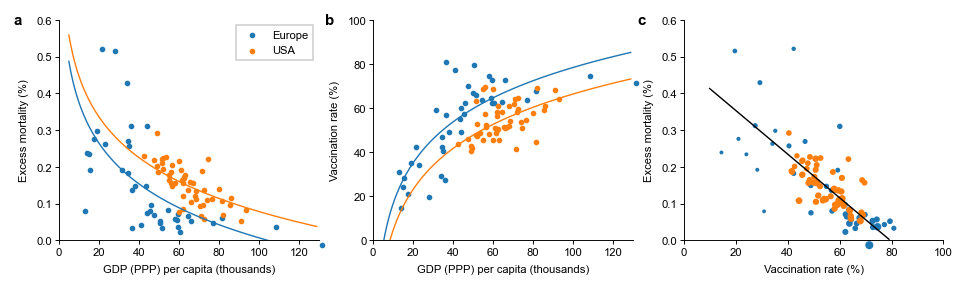

In [8]:
plt.style.use('mpl_style.txt')

############################################################
# Scatter plots

fig, axs = plt.subplots(ncols=3, figsize=(7, 2))

eu = df[df.US == 0]
us = df[df.US == 1]

axs[0].scatter(eu.gdp_ppp / 1000, eu.rel_excess21_22, clip_on=False, label='Europe')
axs[0].scatter(us.gdp_ppp / 1000, us.rel_excess21_22, clip_on=False, label='USA')
axs[0].set_xlim([0, 130])
axs[0].set_ylim([0, 0.6])
axs[0].set_xlabel('GDP (PPP) per capita (thousands)')
axs[0].set_ylabel('Excess mortality (%)')

axs[0].legend(frameon=True)

axs[1].scatter(eu.gdp_ppp / 1000, eu.vacc, clip_on=False)
axs[1].scatter(us.gdp_ppp / 1000, us.vacc, clip_on=False)
axs[1].set_xlim([0, 130])
axs[1].set_ylim([0, 100])
axs[1].set_xlabel('GDP (PPP) per capita (thousands)')
axs[1].set_ylabel('Vaccination rate (%)')

axs[2].scatter(eu.vacc, eu.rel_excess21_22, clip_on=False, s=eu.gdp_ppp/3000)
axs[2].scatter(us.vacc, us.rel_excess21_22, clip_on=False, s=us.gdp_ppp/3000)
# axs[2].scatter(us.vacc[us.gdp>np.median(us.gdp)], us.rel_excess[us.gdp>np.median(us.gdp)], clip_on=False)
axs[2].set_xlim([0, 100])
axs[2].set_ylim([0, 0.6])
axs[2].set_xlabel('Vaccination rate (%)')
axs[2].set_ylabel('Excess mortality (%)')

fig.text(.00, .95, 'a', fontweight='bold', fontsize=8)
fig.text(.33, .95, 'b', fontweight='bold', fontsize=8)
fig.text(.66, .95, 'c', fontweight='bold', fontsize=8)

############################################################
# Model fitting

from scipy.optimize import curve_fit

def myfun1(x, a, b, c):
    y = a * np.log10(x[0,:] / 1000) + b
    us = x[1,:] == 1
    y[us] = a * np.log10(x[:, us][0,:] / 1000 / c) + b
    return y

def myfun2(x, a, b, c):
    y = a * np.log10(x[0,:] / 1000) + b
    us = x[1,:] == 1
    y[us] = a * np.log10(x[:, us][0,:] / 1000 / c) + b
    return y

def myfun(x, a, b, c, d, e):
    y = np.concatenate((
        myfun1(x, a, b, c),
        myfun2(x, d, e, c)
    ))
    return y

X = df[df.region != 'District of Columbia'][['gdp_ppp', 'US']].values
Y = df[df.region != 'District of Columbia'][['rel_excess21_22', 'vacc']].values

stds = np.std(Y, axis=0)
std_ratio = stds[1] / stds[0]
Y[:, 0] = Y[:,0] * std_ratio
print(f'Ratio of standard deviations: {std_ratio:.1f}')

betahat, sigma = curve_fit(myfun, X.T, Y.T.ravel())
print(np.var(Y.T.ravel() - myfun(X.T, *betahat)))

betahat[:2] = betahat[:2] / std_ratio
std_errs = np.sqrt(np.diag(sigma))
std_errs[:2] = std_errs[:2] / std_ratio

print(betahat)
print(std_errs)

############################################################
# Plot the fits

gdpgrid = np.arange(5, 130)
yhat = myfun(np.concatenate((gdpgrid[np.newaxis,:] * 1000, np.zeros_like(gdpgrid)[np.newaxis,:]), axis=0), *betahat)
yhat1 = yhat[:len(yhat)//2]
yhat2 = yhat[len(yhat)//2:]

axs[0].plot(gdpgrid, yhat1)
axs[1].plot(gdpgrid, yhat2)

yhat = myfun(np.concatenate((gdpgrid[np.newaxis,:] * 1000, np.ones_like(gdpgrid)[np.newaxis,:]), axis=0), *betahat)
yhat1 = yhat[:len(yhat)//2]
yhat2 = yhat[len(yhat)//2:]

axs[0].plot(gdpgrid, yhat1)
axs[1].plot(gdpgrid, yhat2)

slope = betahat[0] / betahat[3]
intercept = - slope * betahat[4] + betahat[1]

vaccgrid = np.arange(10, 80)
yhat = vaccgrid * slope + intercept
axs[2].plot(vaccgrid, yhat, 'k')

############################################################
# Save

fig.savefig('us-vs-eu-ppp.png', dpi=300)

Ratio of standard deviations: 140.3
86.13503315821278
[-0.25078006  0.50745932  0.41468125 41.03987818 -4.23303619]
[0.02688439 0.03899585 0.0352742  3.77286701 5.4859252 ]


/home/dmitry/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:47: RuntimeWarning: invalid value encountered in log10
/home/dmitry/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:53: RuntimeWarning: invalid value encountered in log10


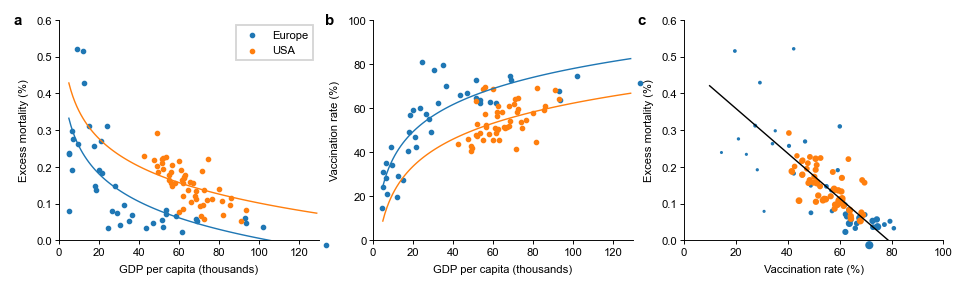

In [71]:
plt.style.use('mpl_style.txt')

############################################################
# Scatter plots

fig, axs = plt.subplots(ncols=3, figsize=(7, 2))

eu = df[df.US == 0]
us = df[df.US == 1]

axs[0].scatter(eu.gdp / 1000, eu.rel_excess21_22, clip_on=False, label='Europe')
axs[0].scatter(us.gdp / 1000, us.rel_excess21_22, clip_on=False, label='USA')
axs[0].set_xlim([0, 130])
axs[0].set_ylim([0, 0.6])
axs[0].set_xlabel('GDP per capita (thousands)')
axs[0].set_ylabel('Excess mortality (%)')

axs[0].legend(frameon=True)

axs[1].scatter(eu.gdp / 1000, eu.vacc, clip_on=False)
axs[1].scatter(us.gdp / 1000, us.vacc, clip_on=False)
axs[1].set_xlim([0, 130])
axs[1].set_ylim([0, 100])
axs[1].set_xlabel('GDP per capita (thousands)')
axs[1].set_ylabel('Vaccination rate (%)')

axs[2].scatter(eu.vacc, eu.rel_excess21_22, clip_on=False, s=eu.gdp/3000)
axs[2].scatter(us.vacc, us.rel_excess21_22, clip_on=False, s=us.gdp/3000)
# axs[2].scatter(us.vacc[us.gdp>np.median(us.gdp)], us.rel_excess[us.gdp>np.median(us.gdp)], clip_on=False)
axs[2].set_xlim([0, 100])
axs[2].set_ylim([0, 0.6])
axs[2].set_xlabel('Vaccination rate (%)')
axs[2].set_ylabel('Excess mortality (%)')

fig.text(.00, .95, 'a', fontweight='bold', fontsize=8)
fig.text(.33, .95, 'b', fontweight='bold', fontsize=8)
fig.text(.66, .95, 'c', fontweight='bold', fontsize=8)

############################################################
# Model fitting

from scipy.optimize import curve_fit

def myfun1(x, a, b, c):
    y = a * np.log10(x[0,:] / 1000) + b
    us = x[1,:] == 1
    y[us] = a * np.log10(x[:, us][0,:] / 1000 * c) + b
    return y

def myfun2(x, a, b, c):
    y = a * np.log10(x[0,:] / 1000) + b
    us = x[1,:] == 1
    y[us] = a * np.log10(x[:, us][0,:] / 1000 * c) + b
    return y

def myfun(x, a, b, c, d, e):
    y = np.concatenate((
        myfun1(x, a, b, c),
        myfun2(x, d, e, c)
    ))
    return y

X = df[df.region != 'District of Columbia'][['gdp', 'US']].values
Y = df[df.region != 'District of Columbia'][['rel_excess21_22', 'vacc']].values

stds = np.std(Y, axis=0)
std_ratio = stds[1] / stds[0]
Y[:, 0] = Y[:, 0] * std_ratio
print(f'Ratio of standard deviations: {std_ratio:.1f}')

betahat, sigma = curve_fit(myfun, X.T, Y.T.ravel())
print(np.var(Y.T.ravel() - myfun(X.T, *betahat)))

betahat[:2] = betahat[:2] / std_ratio
sigma[:2, :] = sigma[:2, :] / std_ratio
sigma[:, :2] = sigma[:, :2] / std_ratio
std_errs = np.sqrt(np.diag(sigma))

print(betahat)
print(std_errs)

############################################################
# Plot the fits

gdpgrid = np.arange(5, 130)
yhat = myfun(np.concatenate((gdpgrid[np.newaxis,:] * 1000, np.zeros_like(gdpgrid)[np.newaxis,:]), axis=0), *betahat)
yhat1 = yhat[:len(yhat)//2]
yhat2 = yhat[len(yhat)//2:]

axs[0].plot(gdpgrid, yhat1)
axs[1].plot(gdpgrid, yhat2)

yhat = myfun(np.concatenate((gdpgrid[np.newaxis,:] * 1000, np.ones_like(gdpgrid)[np.newaxis,:]), axis=0), *betahat)
yhat1 = yhat[:len(yhat)//2]
yhat2 = yhat[len(yhat)//2:]

axs[0].plot(gdpgrid, yhat1)
axs[1].plot(gdpgrid, yhat2)

slope = betahat[0] / betahat[3]
intercept = - slope * betahat[4] + betahat[1]

vaccgrid = np.arange(10, 80)
yhat = vaccgrid * slope + intercept
axs[2].plot(vaccgrid, yhat, 'k')

############################################################
# Save

fig.savefig('us-vs-eu-gdp.png', dpi=300)

In [79]:
us_gdp = df[(df.region != 'District of Columbia') & (df.US == 1)][['gdp']].values
us_exc = df[(df.region != 'District of Columbia') & (df.US == 1)][['rel_excess21_22']].values
us_pop = df[(df.region != 'District of Columbia') & (df.US == 1)][['population']].values

yhat = myfun(np.concatenate((us_gdp, np.zeros_like(us_gdp)), axis=1).T, *betahat)
yhat = yhat[:len(yhat)//2]

print(np.mean(yhat))

print(us_exc.mean())

print(np.sum(yhat.ravel() * us_pop.ravel() / 100))

print(np.sum(us_exc * us_pop / 100))

mm = []
pp = []
for rep in range(10000):
    bh = np.random.multivariate_normal(betahat, sigma)
    yhat = myfun(np.concatenate((us_gdp, np.zeros_like(us_gdp)), axis=1).T, *bh)
    yhat = yhat[:len(yhat)//2]
    mm.append(np.mean(yhat))
    pp.append(np.sum(yhat.ravel() * us_pop.ravel() / 100))
print(np.mean(mm), np.std(mm))
print(np.mean(pp), np.std(pp))

0.055044001734479035
0.152
162169.76610730562
467001.55145
0.055191919880395394 0.013739718888783583
162676.6109873006 47226.54184787307


In [39]:
-0.2507/41.04

-0.0061086744639376215

In [28]:
np.sum(us.excess) / np.sum(us.population) * 100

0.15

gdp = 70_000

print(betahat[0] * np.log10(70 / betahat[2]) + betahat[1])

print(betahat[0] * np.log10(70) + betahat[1])

0.08 * np.sum(us.population) / 100

AttributeError: 'DataFrame' object has no attribute 'excess'

In [22]:
0.134 / 0.045

2.977777777777778

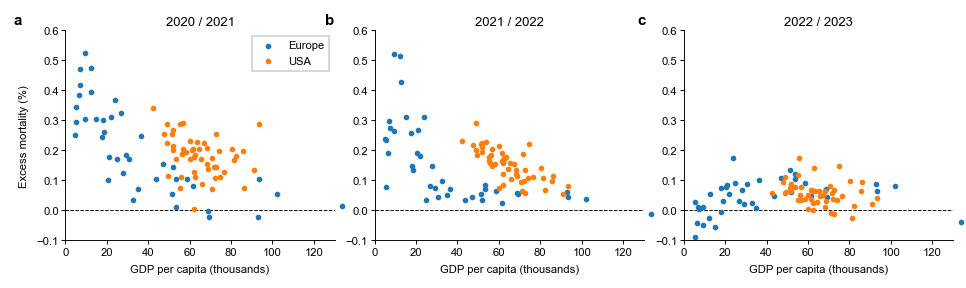

In [47]:
plt.style.use('mpl_style.txt')

fig, axs = plt.subplots(ncols=3, figsize=(7, 2))

eu = df[df.US == 0]
us = df[df.US == 1]

axs[0].scatter(eu.gdp / 1000, eu.rel_excess20_21, clip_on=False, label='Europe')
axs[0].scatter(us.gdp / 1000, us.rel_excess20_21, clip_on=False, label='USA')
axs[0].set_xlim([0, 130])
axs[0].set_ylim([-0.1, 0.6])
axs[0].set_xlabel('GDP per capita (thousands)')
axs[0].set_ylabel('Excess mortality (%)')
axs[0].plot([0, 130], [0, 0], 'k--', lw=.5, zorder=0)
axs[0].set_title('2020 / 2021')

axs[0].legend(frameon=True)

axs[1].scatter(eu.gdp / 1000, eu.rel_excess21_22, clip_on=False, label='Europe')
axs[1].scatter(us.gdp / 1000, us.rel_excess21_22, clip_on=False, label='USA')
axs[1].set_xlim([0, 130])
axs[1].set_ylim([-0.1, 0.6])
axs[1].set_xlabel('GDP per capita (thousands)')
axs[1].plot([0, 130], [0, 0], 'k--', lw=.5, zorder=0)
axs[1].set_title('2021 / 2022')

axs[2].scatter(eu.gdp / 1000, eu.rel_excess22_23, clip_on=False, label='Europe')
axs[2].scatter(us.gdp / 1000, us.rel_excess22_23, clip_on=False, label='USA')
axs[2].set_xlim([0, 130])
axs[2].set_ylim([-0.1, 0.6])
axs[2].set_xlabel('GDP per capita (thousands)')
axs[2].plot([0, 130], [0, 0], 'k--', lw=.5, zorder=0)
axs[2].set_title('2022 / 2023')

fig.text(.00, .95, 'a', fontweight='bold', fontsize=8)
fig.text(.33, .95, 'b', fontweight='bold', fontsize=8)
fig.text(.66, .95, 'c', fontweight='bold', fontsize=8)

fig.savefig('seasons-gdp.png', dpi=300)

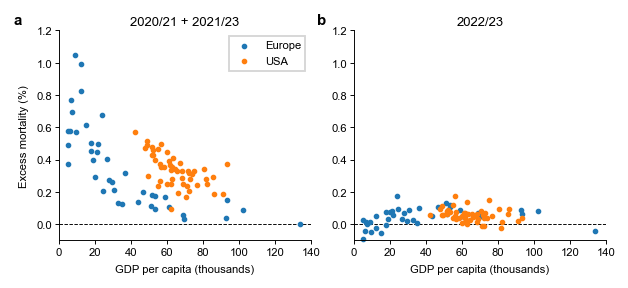

In [41]:
plt.style.use('mpl_style.txt')

fig, axs = plt.subplots(ncols=2, figsize=(4.5, 2))

eu = df[df.US == 0]
us = df[df.US == 1]

axs[0].scatter(eu.gdp / 1000, eu.rel_excess20_21 + eu.rel_excess21_22, clip_on=False, label='Europe')
axs[0].scatter(us.gdp / 1000, us.rel_excess20_21 + us.rel_excess21_22, clip_on=False, label='USA')
axs[0].set_xlim([0, 140])
axs[0].set_ylim([-0.1, 1.2])
axs[0].set_xlabel('GDP per capita (thousands)')
axs[0].set_ylabel('Excess mortality (%)')
axs[0].plot([0, 140], [0, 0], 'k--', lw=.5, zorder=0)
axs[0].set_title('2020/21 + 2021/23')

axs[0].legend(frameon=True)

axs[1].scatter(eu.gdp / 1000, eu.rel_excess22_23, clip_on=False, label='Europe')
axs[1].scatter(us.gdp / 1000, us.rel_excess22_23, clip_on=False, label='USA')
axs[1].set_xlim([0, 140])
axs[1].set_ylim([-0.1, 1.2])
axs[1].set_xlabel('GDP per capita (thousands)')
axs[1].plot([0, 140], [0, 0], 'k--', lw=.5, zorder=0)
axs[1].set_title('2022/23')

fig.text(.00, .95, 'a', fontweight='bold', fontsize=8)
fig.text(.50, .95, 'b', fontweight='bold', fontsize=8)

fig.savefig('two-seasons-gdp.png', dpi=300)